In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings

warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('online_vs_offline_learning_dataset.csv')

df.head()

,Learning_Mode,Subject,Study_Hours,Retention_Score,Focus_Level,Exam_Score
0,Offline,English,7.7,51,96,70
1,Offline,English,6.2,90,82,81
2,Online,English,1.2,75,66,71
3,Online,Math,6.5,80,64,77
4,Online,English,5.5,95,58,78


In [4]:
print(df.isna().sum().sort_values(ascending=False))

Learning_Mode      0
Subject            0
Study_Hours        0
Retention_Score    0
Focus_Level        0
Exam_Score         0
dtype: int64


In [6]:
df.describe()

,Study_Hours,Retention_Score,Focus_Level,Exam_Score
count,1000.000000,1000.00000,1000.000000,1000.000000
mean,4.563500,72.69100,71.261000,71.675000
std,2.000115,17.69827,18.053166,12.984297
min,1.000000,40.00000,40.000000,39.000000
25%,2.800000,58.00000,56.000000,62.000000
50%,4.700000,72.00000,72.000000,72.000000
75%,6.300000,88.00000,87.000000,81.000000
max,8.000000,100.00000,100.000000,100.000000


In [7]:
df.shape

(1000, 6)

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoders = {}  

for col in ['Subject', 'Learning_Mode']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

In [17]:
df.head()

,Learning_Mode,Subject,Study_Hours,Retention_Score,Focus_Level,Exam_Score
0,0,0,7.7,51,96,70
1,0,0,6.2,90,82,81
2,1,0,1.2,75,66,71
3,1,2,6.5,80,64,77
4,1,0,5.5,95,58,78


In [18]:
X = df.drop(columns='Exam_Score', axis=1)
y = df['Exam_Score']

In [20]:
X.shape

(1000, 5)

In [22]:
y.shape

(1000,)

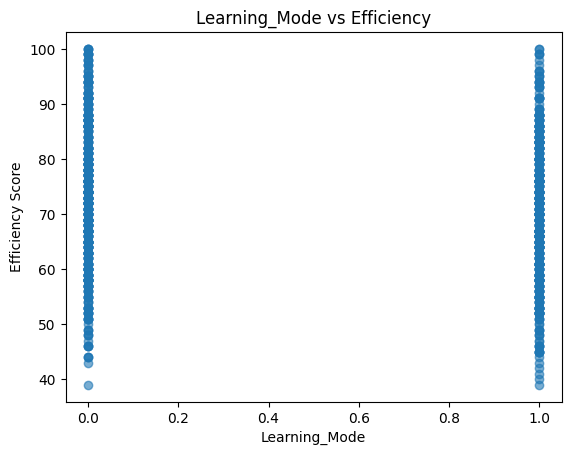

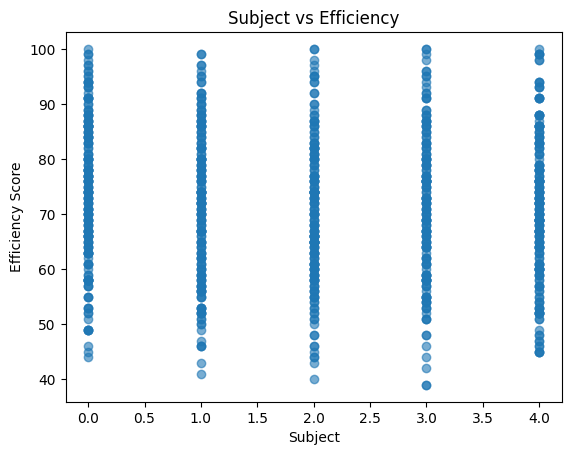

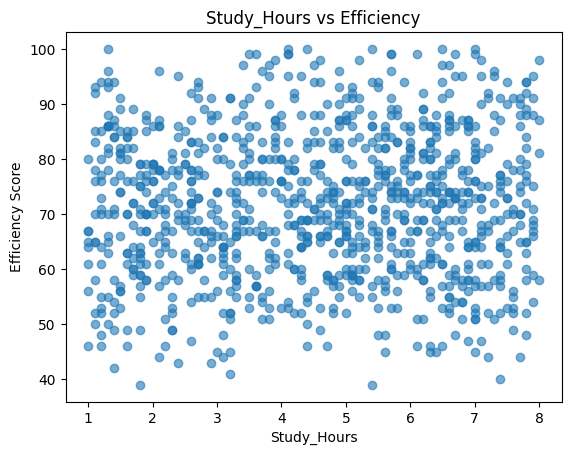

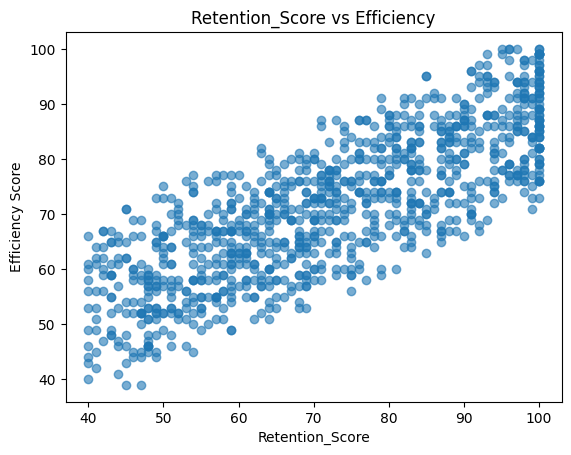

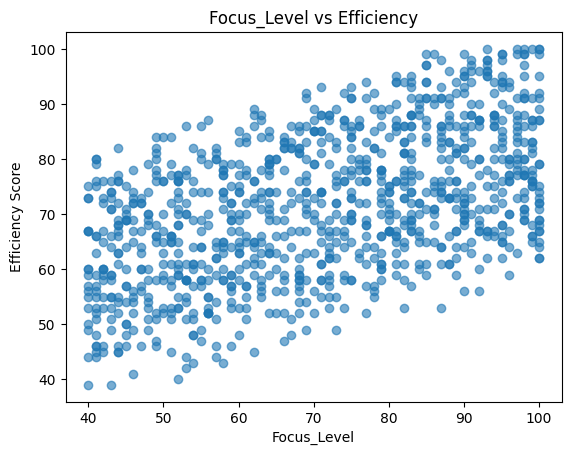

In [24]:
for col in X.columns:
    plt.scatter(df[col], y, alpha=0.6)
    plt.xlabel(col)
    plt.ylabel('Efficiency Score')
    plt.title(f'{col} vs Efficiency')
    plt.show()

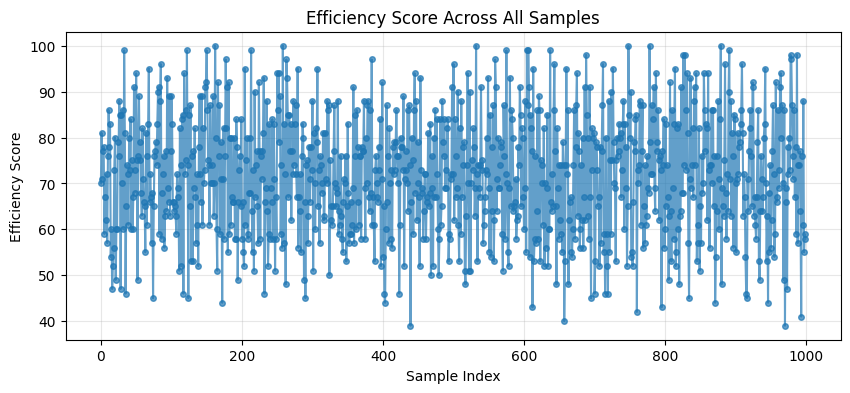

In [25]:
plt.figure(figsize=(10, 4))
plt.plot(y.values, marker='o', linestyle='-', markersize=4, alpha=0.7)
plt.title('Efficiency Score Across All Samples')
plt.xlabel('Sample Index')
plt.ylabel('Efficiency Score')
plt.grid(True, alpha=0.3)
plt.show()

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

In [27]:
X_train.shape

(800, 5)

In [28]:
# Model 1 : DecisionTreeRegressor

model1 = DecisionTreeRegressor()

model1.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [30]:
preds1 = model1.predict(X_test)

print("Decision Tree Regressor:")
print(f"MAE: {mean_absolute_error(y_test, preds1):.3f}")
print(f"R² : {r2_score(y_test, preds1):.3f}")

Decision Tree Regressor:
MAE: 3.525
R² : 0.883


In [31]:
# Model 2 : RandomForestRegressor

model2 = RandomForestRegressor()

model2.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
preds2 = model2.predict(X_test)

print("Random Forest Regressor:")
print(f"MAE: {mean_absolute_error(y_test, preds2):.3f}")
print(f"R² : {r2_score(y_test, preds2):.3f}")

Decision Tree Regressor:
MAE: 2.732
R² : 0.932


In [36]:
# How much will i score according to this Model !
your_data = pd.DataFrame({
    'Subject': [2],          
    'Learning_Mode': [1],    
    'Study_Hours': [2.5],
    'Retention_Score': [50], 
    'Focus_Level': [50]      
})

scaler = StandardScaler()

your_data_scaled = scaler.fit_transform(your_data)  


# Model 1
pred = model1.predict(your_data_scaled)
print(f"Your predicted Efficiency Score: {pred[0]:.1f}%")

# Model 2
pred = model2.predict(your_data_scaled)
print(f"Your predicted Efficiency Score: {pred[0]:.1f}%")

Your predicted Efficiency Score: 39.0%
Your predicted Efficiency Score: 42.8%


In [40]:
# Yeah this model is making me crazyy !!